# Jax PM RESULTS


In [14]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import pickle
import numpy as np
import jax
import jax.numpy as jnp
import jax_cosmo as jc
import haiku as hk
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm import tqdm
from jax.experimental.ode import odeint

# Módulos del proyecto — ajusta sys.path si es necesario
import sys
sys.path.insert(0, "/cosmos_storage/home/diegovillalba/JaxPM/")

from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.kernels import fftk
from jaxpm.pm import make_ode_fn, get_delta

# Para reconstruir los modelos
from jaxpm.nn import CNN, NeuralSplineFourierFilter

jax.config.update("jax_enable_x64", False)
print(f"JAX devices: {jax.devices()}")

JAX devices: [CudaDevice(id=0)]


## 1. Rutas y configuración

In [15]:
# ── Ajusta estas rutas ──────────────────────────────────────────────
DATA_DIR   = Path("/cosmos_storage/home/diegovillalba/JaxPM/data/matched_128_256_L256.0_S50_Np128")
MODELS_DIR = Path("/cosmos_storage/home/diegovillalba/JaxPM/models")

MESH_LR   = 128
MESH_HR   = 256
BOX_SIZE  = 256.0  # Mpc/h
N_TEST    = 5      # número de sims de test a evaluar por corrida
TEST_SIM_IDS = list(range(90, 90 + N_TEST))  # IDs de las sims de test

COSMOLOGY = jc.Planck15(Omega_c=0.25, sigma8=0.8)

# ── Checkpoints a comparar ──────────────────────────────────────────
# Cada entrada: nombre_display -> ruta al .pkl de best weights
RUNS = {
    "LR (baseline)": None,   # sin modelo; se calcula directo de pos_lr
    "cnn electric-dream" : MODELS_DIR / "electric-dream-78/best_*.pkl",
    "kcorr gallant-lion-73" : MODELS_DIR / "gallant-lion-73/best_*.pkl",
    "cnn lemon-cloud-74" : MODELS_DIR / "lemon-cloud-74/best_*.pkl",
    "cnn revived-grass-60" : MODELS_DIR / "revived-grass-60/best_*.pkl",
    "kcorr royal-energy-58"        : MODELS_DIR / "royal-energy-58/best_*.pkl",
    "cnn volcanic-plasma-59"     : MODELS_DIR / "volcanic-plasma-59/best_*.pkl",
    "cnn young-field-77"       : MODELS_DIR / "young-field-77/best_*.pkl",
    "cnn glorious-wood-80"     : MODELS_DIR / "glorious-wood-80/best_*.pkl",
    # "cnn+kcorr"  : MODELS_DIR / "<nombre_run>/best_*.pkl",
}

# Parámetros del modelo CNN (deben coincidir con el run)
CNN_CFG = dict(
    channels_hidden_dim=16,
    n_convolutions=3,
    n_fully_connected=2,
    input_dim=1,
    kernel_size=3,
    pad_periodic=True,
    embed_globals=False,
    n_globals_embedding=1,
    globals_embedding_dim=64,
    global_conditioning="add",
    use_attention_interpolation=False,
    add_particle_velocities=True,
)

KCORR_CFG = dict(n_knots=16, latent_size=64)

print("Configuración cargada.")

Configuración cargada.


## 2. Helpers: carga de datos y modelos

In [16]:
# def load_sim(sim_id, mesh_lr=MESH_LR, mesh_hr=MESH_HR):
#     """Carga posiciones, velocidades y factor de escala para una sim."""
#     pos_lr  = jnp.array(np.load(DATA_DIR / f"pos_m{mesh_lr}_s{sim_id}.npy"))
#     vel_lr  = jnp.array(np.load(DATA_DIR / f"vel_m{mesh_lr}_s{sim_id}.npy"))
#     pos_hr  = jnp.array(np.load(DATA_DIR / f"pos_m{mesh_hr}_s{sim_id}.npy"))
#     vel_hr  = jnp.array(np.load(DATA_DIR / f"vel_m{mesh_hr}_s{sim_id}.npy"))
#     avals   = jnp.array(np.load(DATA_DIR / "scale_factors.npy"))
#     # Convertir a mesh units
#     pos_lr  = pos_lr / BOX_SIZE * mesh_lr
#     pos_hr  = pos_hr / BOX_SIZE * mesh_lr   # HR en unidades del mesh LR para comparación
#     vel_lr  = vel_lr / BOX_SIZE * mesh_lr
#     vel_hr  = vel_hr / BOX_SIZE * mesh_lr
#     return pos_lr, vel_lr, pos_hr, vel_hr, avals
# ── load_sim CORRECTO ──────────────────────────────────────────────
def load_sim(sim_id, mesh_lr=MESH_LR, mesh_hr=MESH_HR):
    """
    Los archivos en disco están en unidades físicas [0, 256) Mpc/h
    (generate_data.py línea 214: pos / mesh * L)
    Convertimos a mesh_lr units [0, 128) igual que hace read_data.py
    """
    pos_lr = np.load(DATA_DIR / f"pos_m{mesh_lr}_s{sim_id}.npy")  # [0, 256)
    vel_lr = np.load(DATA_DIR / f"vel_m{mesh_lr}_s{sim_id}.npy")
    pos_hr = np.load(DATA_DIR / f"pos_m{mesh_hr}_s{sim_id}.npy")  # [0, 256)
    vel_hr = np.load(DATA_DIR / f"vel_m{mesh_hr}_s{sim_id}.npy")
    avals  = np.load(DATA_DIR / "scale_factors.npy")

    BOX_SIZE = 256.0

    # Una sola conversión: físicas → mesh_lr units (igual que read_data.py)
    pos_lr = jnp.array(pos_lr / BOX_SIZE * mesh_lr, dtype=jnp.float32)
    vel_lr = jnp.array(vel_lr / BOX_SIZE * mesh_lr, dtype=jnp.float32)
    pos_hr = jnp.array(pos_hr / BOX_SIZE * mesh_lr, dtype=jnp.float32)  # HR también en mesh_lr
    vel_hr = jnp.array(vel_hr / BOX_SIZE * mesh_lr, dtype=jnp.float32)
    avals  = jnp.array(avals)

    return pos_lr, vel_lr, pos_hr, vel_hr, avals

def glob_best_pkl(run_path):
    """Resuelve glob en ruta de checkpoint."""
    p = Path(str(run_path))
    if '*' in str(p):
        candidates = sorted(p.parent.glob(p.name))
        assert len(candidates) > 0, f"No se encontró ningún pkl en {p}"
        return candidates[-1]   # toma el más reciente si hay varios
    return p


def load_params(pkl_path):
    with open(glob_best_pkl(pkl_path), "rb") as f:
        return pickle.load(f)


def build_cnn_model():
    def CNNCorr(x, positions, scale_factors, velocities):
        return CNN(**CNN_CFG)(x=x, positions=positions,
                              global_features=scale_factors,
                              velocities=velocities)
    return hk.without_apply_rng(hk.transform(CNNCorr))


def build_kcorr_model():
    def KCorr(x, scale_factors):
        return NeuralSplineFourierFilter(**KCORR_CFG)(x, scale_factors)
    return hk.without_apply_rng(hk.transform(KCorr))


def infer_model_type(run_name):
    if run_name == "LR (baseline)":
        return None
    if "kcorr" in run_name and "cnn" not in run_name:
        return "kcorr"
    if "cnn+kcorr" in run_name:
        return "cnn+kcorr"
    return "cnn"


print("Helpers definidos.")

Helpers definidos.


## 3. Funciones de métricas
Reusan `power_spectrum` y `cross_correlation_coefficients` de `jaxpm.utils`.

In [17]:
BOXSIZE_ARR = np.array([BOX_SIZE] * 3)
KMIN        = np.pi / BOX_SIZE
DK          = 2 * np.pi / BOX_SIZE


def positions_to_delta(pos, n_mesh=MESH_LR):
    """CIC deposit → delta field en mesh_lr."""
    pos_wrap = jnp.mod(pos, n_mesh)
    return get_delta(pos_wrap, (n_mesh, n_mesh, n_mesh))


def compute_pk_ratio(delta_pm, delta_hr):
    """P(k)_pm / P(k)_hr usando compensate_cic + power_spectrum existentes."""
    k, pk_pm = power_spectrum(compensate_cic(delta_pm),
                               boxsize=BOXSIZE_ARR, kmin=KMIN, dk=DK)
    _, pk_hr = power_spectrum(compensate_cic(delta_hr),
                               boxsize=BOXSIZE_ARR, kmin=KMIN, dk=DK)
    valid = (pk_hr > 0) & jnp.isfinite(pk_hr) & jnp.isfinite(pk_pm)
    ratio = jnp.where(valid, pk_pm / pk_hr, jnp.nan)
    return np.asarray(k), np.asarray(ratio)


def compute_cross_corr(delta_pm, delta_hr):
    """r(k) = P_cross / sqrt(P_pm * P_hr)."""
    k, p_cross = cross_correlation_coefficients(
        compensate_cic(delta_hr), compensate_cic(delta_pm),
        boxsize=BOXSIZE_ARR, kmin=KMIN, dk=DK)
    _, pk_pm = power_spectrum(compensate_cic(delta_pm),
                               boxsize=BOXSIZE_ARR, kmin=KMIN, dk=DK)
    _, pk_hr = power_spectrum(compensate_cic(delta_hr),
                               boxsize=BOXSIZE_ARR, kmin=KMIN, dk=DK)
    denom = jnp.sqrt(jnp.clip(pk_pm * pk_hr, 1e-30))
    r = jnp.real(p_cross) / denom
    return np.asarray(k), np.asarray(r)


def compute_pos_mse(pos_pm, pos_hr, n_mesh=MESH_LR):
    """MSE de posiciones con distancia mínima imagen periódica."""
    n  = float(n_mesh)
    d  = pos_pm - pos_hr
    d  = d - n * jnp.round(d / n)
    return float(jnp.mean(jnp.sum(d ** 2, axis=-1)) / n ** 2)


# def run_ode_with_model(pos_lr_0, vel_lr_0, avals, model, params, correction_type):
#     """Integra la ODE con corrección neuronal."""
#     mesh_shape = (MESH_LR, MESH_LR, MESH_LR)
#     pos_pm, vel_pm = odeint(
#         make_ode_fn(mesh_shape=mesh_shape,
#                     add_correction=correction_type,
#                     model=model),
#         [pos_lr_0, vel_lr_0],
#         avals,
#         COSMOLOGY,
#         params,
#         rtol=1e-5, atol=1e-5,
#     )
#     return jnp.mod(pos_pm, MESH_LR), vel_pm
# ── run_ode_with_model CORRECTO ────────────────────────────────────
def run_ode_with_model(pos_lr_0, vel_lr_0, avals, model, params, correction_type):
    """
    Corre el ODE directamente en mesh units.
    NO usar loss_fn — devuelve pos_pm wrapeado que destruye la estructura.
    """
    mesh_shape = (MESH_LR, MESH_LR, MESH_LR)
    pos_pm, vel_pm = odeint(
        make_ode_fn(
            mesh_shape=mesh_shape,
            add_correction=correction_type,
            model=model,
        ),
        [pos_lr_0, vel_lr_0],
        avals,
        COSMOLOGY,
        params,
        rtol=1e-5,
        atol=1e-5,
    )
    # NO aplicar mod — dejar el rango natural con negativos posibles
    # El mod solo se aplica en slab_projection al momento del CIC deposit
    return pos_pm, vel_pm
print("Funciones de métricas definidas.")

Funciones de métricas definidas.


## 4. Loop de evaluación principal

In [18]:
results   = {}
k_bins    = None
SNAP_EVAL = [0, 12, 24, 37, 49]

for run_name, pkl_path in RUNS.items():
    print(f"\n{'='*55}")
    print(f"  Evaluando: {run_name}")
    print(f"{'='*55}")

    correction_type = infer_model_type(run_name)

    if pkl_path is not None:
        params = load_params(pkl_path)
        if correction_type == "kcorr":
            model = build_kcorr_model()
        elif correction_type == "cnn+kcorr":
            model = {"cnn": build_cnn_model(), "kcorr": build_kcorr_model()}
        else:
            model = build_cnn_model()
    else:
        params = None
        model  = None

    run_results = {}

    for sim_id in tqdm(TEST_SIM_IDS, desc=run_name):
        pos_lr, vel_lr, pos_hr, vel_hr, avals = load_sim(sim_id)

        if correction_type is None:
            pos_pm = jnp.mod(pos_lr, MESH_LR)
        else:
            pos_pm, _ = run_ode_with_model(
                pos_lr[0], vel_lr[0], avals, model, params, correction_type
            )

        # FIX 1: bajar pos_pm completo a CPU inmediatamente — libera ~1.2 GB de GPU
        pos_pm_cpu = np.asarray(jax.device_get(pos_pm))
        pos_hr_cpu = np.asarray(jax.device_get(pos_hr))
        del pos_pm, pos_lr, vel_lr, vel_hr   # pos_lr ya se borra aquí
        jax.clear_caches()            # limpia buffers de compilación JIT

        sim_metrics = {"pk_ratio": [], "cross_corr": [], "pos_mse": [], "avals": []}

        for snap_idx in SNAP_EVAL:
            # FIX 2: subir solo el snapshot que necesitas, no todo el array
            p_pm = jnp.array(pos_pm_cpu[snap_idx])
            p_hr = jnp.mod(jnp.array(pos_hr_cpu[snap_idx]), MESH_LR)

            delta_pm = positions_to_delta(p_pm)
            delta_hr = positions_to_delta(p_hr)

            k, ratio = compute_pk_ratio(delta_pm, delta_hr)
            _, r_k   = compute_cross_corr(delta_pm, delta_hr)
            mse      = compute_pos_mse(p_pm, p_hr)

            # FIX 3: bajar métricas a numpy inmediatamente y liberar device arrays
            sim_metrics["pk_ratio"].append(np.asarray(jax.device_get(ratio)))
            sim_metrics["cross_corr"].append(np.asarray(jax.device_get(r_k)))
            sim_metrics["pos_mse"].append(float(jax.device_get(mse)))
            sim_metrics["avals"].append(float(avals[snap_idx]))

            if k_bins is None:
                k_bins = np.asarray(k)

            # FIX 4: liberar deltas y slices después de cada snapshot
            del p_pm, p_hr, delta_pm, delta_hr, ratio, r_k, mse

        run_results[sim_id] = sim_metrics

        # FIX 5: liberar arrays CPU del sim actual antes del siguiente
        del pos_pm_cpu, pos_hr_cpu 

    results[run_name] = run_results

    # FIX 6: liberar params del modelo actual antes de cargar el siguiente
    del params, model
    jax.clear_caches()

    print(f"  ✓ {run_name} completado.")

print("\nEvaluación completa.")


  Evaluando: LR (baseline)


LR (baseline): 100%|██████████| 5/5 [00:43<00:00,  8.61s/it]


  ✓ LR (baseline) completado.

  Evaluando: cnn electric-dream


cnn electric-dream: 100%|██████████| 5/5 [01:21<00:00, 16.30s/it]


  ✓ cnn electric-dream completado.

  Evaluando: kcorr gallant-lion-73


kcorr gallant-lion-73: 100%|██████████| 5/5 [01:00<00:00, 12.18s/it]


  ✓ kcorr gallant-lion-73 completado.

  Evaluando: cnn lemon-cloud-74


cnn lemon-cloud-74:   0%|          | 0/5 [00:09<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
for _var in ["avals", "k", "pos_pm_cpu", "pos_hr_cpu",
             "p_pm", "p_hr", "delta_pm", "delta_hr",
             "ratio", "r_k", "mse", "params", "model"]:
    if _var in locals():
        del _var
jax.clear_caches()

## 5. Estadísticas resumen (media ± std)

In [ ]:
import pandas as pd
import scienceplots
plt.style.use('science')
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",   # O 'sans-serif' si lo prefieres
    "mathtext.fontset": "dejavuserif" # Para que las fórmulas simples se vean bien sin LaTeX
})

def aggregate_metrics(results, k_bins, snap_eval_indices):
    """
    Para cada run y cada snapshot:
      - pk_ratio:   media y std sobre sims, evaluado en k_bins
      - cross_corr: ídem
      - pos_mse:    escalar, media y std sobre sims
    Devuelve dict anidado: agg[run_name][snap_idx] = {medias, stds}
    """
    agg = {}
    for run_name, run_res in results.items():
        agg[run_name] = {}
        for i, snap_idx in enumerate(snap_eval_indices):
            all_ratio  = np.stack([run_res[s]["pk_ratio"][i]  for s in run_res])
            all_corr   = np.stack([run_res[s]["cross_corr"][i] for s in run_res])
            all_mse    = np.array([run_res[s]["pos_mse"][i]   for s in run_res])
            a_val      = list(run_res.values())[0]["avals"][i]

            agg[run_name][snap_idx] = {
                "a"           : a_val,
                "pk_ratio_mean": np.nanmean(all_ratio, axis=0),
                "pk_ratio_std" : np.nanstd(all_ratio,  axis=0),
                "cross_corr_mean": np.nanmean(all_corr, axis=0),
                "cross_corr_std" : np.nanstd(all_corr,  axis=0),
                "pos_mse_mean": float(np.mean(all_mse)),
                "pos_mse_std" : float(np.std(all_mse)),
            }
    return agg


agg = aggregate_metrics(results, k_bins, SNAP_EVAL)

# ── Tabla resumen de pos_mse por run y snapshot ──────────────────────
rows = []
for run_name in results:
    for i, snap_idx in enumerate(SNAP_EVAL):
        d = agg[run_name][snap_idx]
        rows.append({
            "run"        : run_name,
            "snap"       : snap_idx,
            "a"          : f"{d['a']:.2f}",
            "pos_mse"    : f"{d['pos_mse_mean']:.5f} ± {d['pos_mse_std']:.5f}",
        })

df_mse = pd.DataFrame(rows).pivot(index="run", columns=["snap", "a"], values="pos_mse")
print("\n── Pos MSE (media ± std sobre sims de test) ──")
display(df_mse)

# ── Tabla resumen de pk_ratio en k específicos ───────────────────────
# Seleccionamos k~0.3, ~0.6, ~1.0 h/Mpc como referencia
k_sel = [0.3, 0.6, 1.0]
rows_pk = []
for run_name in results:
    for i, snap_idx in enumerate(SNAP_EVAL):
        d = agg[run_name][snap_idx]
        for kref in k_sel:
            idx_k = int(np.argmin(np.abs(k_bins - kref)))
            rows_pk.append({
                "run"  : run_name,
                "a"    : f"{d['a']:.2f}",
                f"P(k)/P_HR @ k≈{kref}": (
                    f"{d['pk_ratio_mean'][idx_k]:.3f} ± {d['pk_ratio_std'][idx_k]:.3f}"
                ),
            })

print("\n── P(k)/P_HR en k representativos (snapshot final, a=1.0) ──")
df_pk = pd.DataFrame(
    [{"run": run_name,
      **{f"k≈{kref}": (
          f"{agg[run_name][SNAP_EVAL[-1]]['pk_ratio_mean'][int(np.argmin(np.abs(k_bins - kref)))]:.3f}"
          f" ± {agg[run_name][SNAP_EVAL[-1]]['pk_ratio_std'][int(np.argmin(np.abs(k_bins - kref)))]:.3f}"
      ) for kref in k_sel}}
     for run_name in results]
).set_index("run")
display(df_pk)


── Pos MSE (media ± std sobre sims de test) ──


snap,0,12,24,37,49
a,0.10,0.32,0.54,0.78,1.00
run,,,,,
LR (baseline),0.00000 ± 0.00000,0.00000 ± 0.00000,0.00001 ± 0.00000,0.00002 ± 0.00000,0.00003 ± 0.00000
cnn electric-dream,0.00000 ± 0.00000,0.00000 ± 0.00000,0.00001 ± 0.00000,0.00001 ± 0.00000,0.00002 ± 0.00000
cnn glorious-wood-80,0.00000 ± 0.00000,0.00000 ± 0.00000,0.00001 ± 0.00000,0.00001 ± 0.00000,0.00002 ± 0.00000
cnn lemon-cloud-74,0.00000 ± 0.00000,0.00002 ± 0.00000,0.00009 ± 0.00001,0.00020 ± 0.00001,0.00030 ± 0.00002
cnn revived-grass-60,0.00000 ± 0.00000,0.00000 ± 0.00000,0.00001 ± 0.00000,0.00001 ± 0.00000,0.00002 ± 0.00000
cnn volcanic-plasma-59,0.00000 ± 0.00000,0.00000 ± 0.00000,0.00001 ± 0.00000,0.00001 ± 0.00000,0.00002 ± 0.00000
cnn young-field-77,0.00000 ± 0.00000,0.00000 ± 0.00000,0.00001 ± 0.00000,0.00001 ± 0.00000,0.00002 ± 0.00000
kcorr gallant-lion-73,0.00000 ± 0.00000,0.00001 ± 0.00000,0.00007 ± 0.00000,0.00019 ± 0.00002,0.00032 ± 0.00003



── P(k)/P_HR en k representativos (snapshot final, a=1.0) ──


,k≈0.3,k≈0.6,k≈1.0
run,,,
LR (baseline),0.961 ± 0.001,0.881 ± 0.003,0.749 ± 0.010
cnn electric-dream,1.012 ± 0.006,1.016 ± 0.004,0.952 ± 0.011
kcorr gallant-lion-73,0.598 ± 0.024,0.610 ± 0.017,0.534 ± 0.012
cnn lemon-cloud-74,0.300 ± 0.014,0.301 ± 0.008,0.242 ± 0.006
cnn revived-grass-60,1.020 ± 0.005,1.027 ± 0.004,0.949 ± 0.012
kcorr royal-energy-58,0.999 ± 0.002,1.028 ± 0.008,0.950 ± 0.007
cnn volcanic-plasma-59,1.019 ± 0.005,1.030 ± 0.004,0.952 ± 0.012
cnn young-field-77,1.019 ± 0.005,1.030 ± 0.004,0.952 ± 0.012
cnn glorious-wood-80,1.031 ± 0.006,1.032 ± 0.005,0.932 ± 0.012


## 6. Panel de comparación — P(k)/P_HR(k) por snapshot

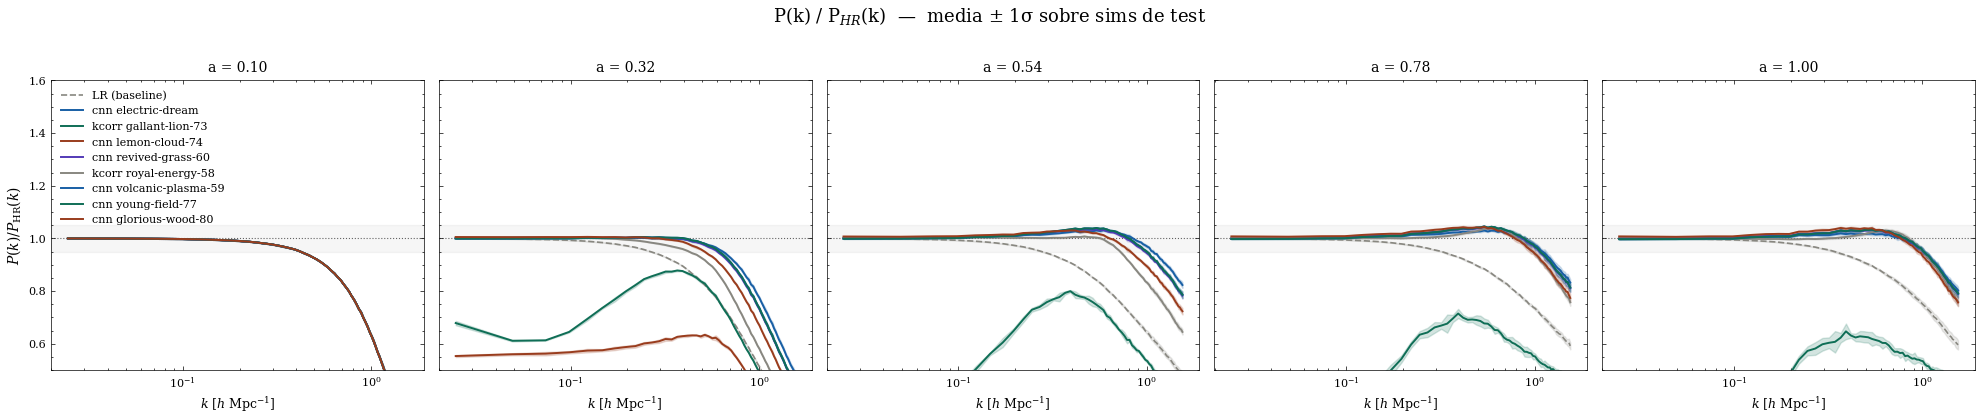

Guardado: pk_ratio_comparison.pdf


In [ ]:
COLORS  = ["#888780", "#185FA5", "#0F6E56", "#993C1D", "#533AB7"]
LS_MAP  = {
    "LR (baseline)": ("--", 1.2),
    "kcorr"        : ("-",  1.6),
    "cnn"          : ("-",  1.6),
    "cnn+kcorr"    : ("-",  1.8),
}

run_names = list(results.keys())
n_snaps   = len(SNAP_EVAL)

fig, axes = plt.subplots(1, n_snaps, figsize=(4 * n_snaps, 4.2), sharey=True)
fig.suptitle("P(k) / P$_{HR}$(k)  —  media ± 1σ sobre sims de test",
             fontsize=13, y=1.01)

for col, snap_idx in enumerate(SNAP_EVAL):
    ax = axes[col]
    a_val = list(agg[run_names[0]].values())[col]["a"]
    ax.set_title(f"a = {a_val:.2f}", fontsize=10)
    ax.axhline(1.0, color="black", lw=0.8, ls=":", alpha=0.6)
    ax.axhspan(0.95, 1.05, alpha=0.07, color="gray")   # banda ±5%

    for ci, run_name in enumerate(run_names):
        d   = agg[run_name][snap_idx]
        mu  = d["pk_ratio_mean"]
        sig = d["pk_ratio_std"]
        ls, lw = LS_MAP.get(run_name, ("-", 1.4))
        color   = COLORS[ci % len(COLORS)]

        ax.semilogx(k_bins, mu, ls=ls, lw=lw, color=color,
                    label=run_name if col == 0 else None)
        ax.fill_between(k_bins, mu - sig, mu + sig,
                        alpha=0.18, color=color)

    ax.set_xlabel(r"$k$ [$h$ Mpc$^{-1}$]", fontsize=9)
    ax.set_ylim(0.5, 1.6)
    ax.tick_params(labelsize=8)
    if col == 0:
        ax.set_ylabel(r"$P(k)/P_{\rm HR}(k)$", fontsize=10)

axes[0].legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig("pk_ratio_comparison.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Guardado: pk_ratio_comparison.pdf")

## 7. Panel de comparación — cross-correlation r(k)

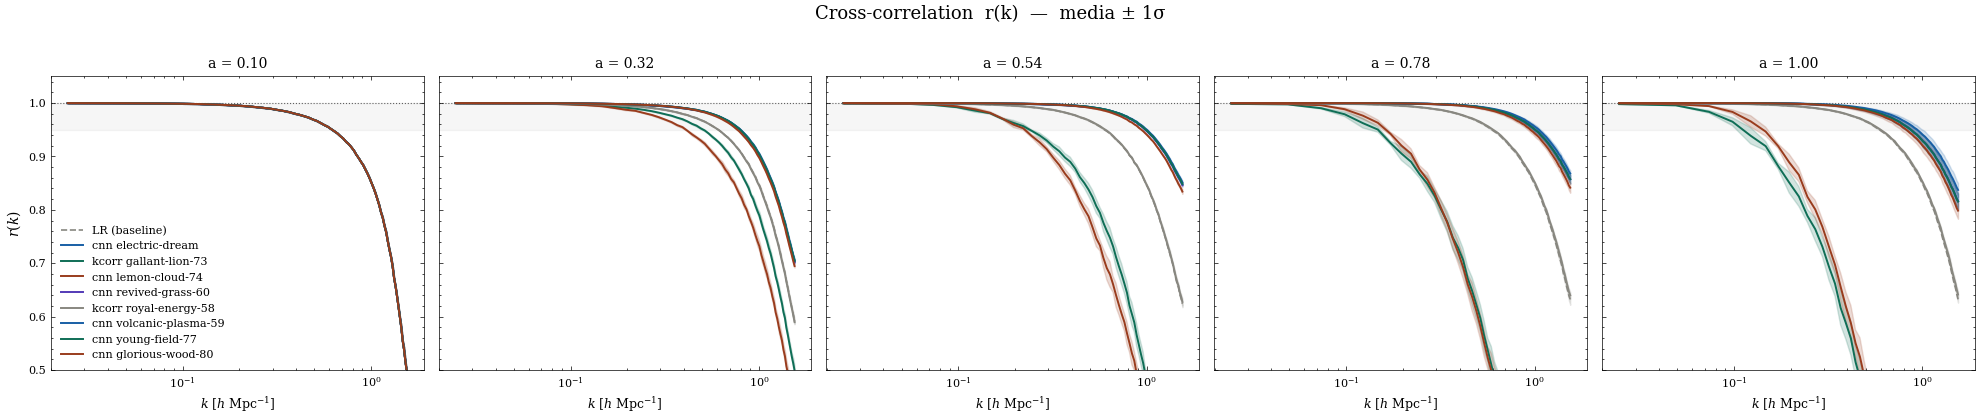

Guardado: cross_corr_comparison.pdf


In [ ]:
fig, axes = plt.subplots(1, n_snaps, figsize=(4 * n_snaps, 4.2), sharey=True)
fig.suptitle("Cross-correlation  r(k)  —  media ± 1σ",
             fontsize=13, y=1.01)

for col, snap_idx in enumerate(SNAP_EVAL):
    ax = axes[col]
    a_val = list(agg[run_names[0]].values())[col]["a"]
    ax.set_title(f"a = {a_val:.2f}", fontsize=10)
    ax.axhline(1.0, color="black", lw=0.8, ls=":", alpha=0.6)
    ax.axhspan(0.95, 1.0, alpha=0.07, color="gray")

    for ci, run_name in enumerate(run_names):
        d   = agg[run_name][snap_idx]
        mu  = d["cross_corr_mean"]
        sig = d["cross_corr_std"]
        ls, lw = LS_MAP.get(run_name, ("-", 1.4))
        color   = COLORS[ci % len(COLORS)]

        ax.semilogx(k_bins, mu, ls=ls, lw=lw, color=color,
                    label=run_name if col == 0 else None)
        ax.fill_between(k_bins, mu - sig, mu + sig,
                        alpha=0.18, color=color)

    ax.set_xlabel(r"$k$ [$h$ Mpc$^{-1}$]", fontsize=9)
    ax.set_ylim(0.5, 1.05)
    ax.tick_params(labelsize=8)
    if col == 0:
        ax.set_ylabel(r"$r(k)$", fontsize=10)

axes[0].legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.savefig("cross_corr_comparison.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Guardado: cross_corr_comparison.pdf")

## 8. Panel de comparación — Pos MSE vs scale factor

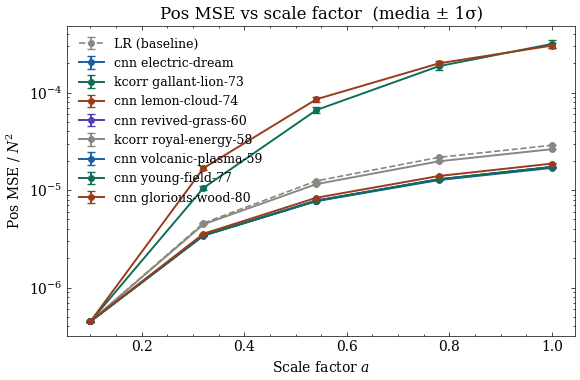

Guardado: pos_mse_vs_a.pdf


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.set_title("Pos MSE vs scale factor  (media ± 1σ)", fontsize=12)

for ci, run_name in enumerate(run_names):
    a_vals  = [agg[run_name][s]["a"]            for s in SNAP_EVAL]
    mu_vals = [agg[run_name][s]["pos_mse_mean"] for s in SNAP_EVAL]
    sd_vals = [agg[run_name][s]["pos_mse_std"]  for s in SNAP_EVAL]
    ls, lw  = LS_MAP.get(run_name, ("-", 1.4))
    color   = COLORS[ci % len(COLORS)]

    ax.errorbar(a_vals, mu_vals, yerr=sd_vals,
                fmt=f"{ls}o", lw=lw, ms=4,
                color=color, label=run_name, capsize=3)

ax.set_xlabel(r"Scale factor $a$", fontsize=10)
ax.set_ylabel(r"Pos MSE / $N^2$", fontsize=10)
ax.legend(fontsize=9)
ax.set_yscale("log")
plt.tight_layout()
plt.savefig("pos_mse_vs_a.pdf", bbox_inches="tight", dpi=300)
plt.show()
print("Guardado: pos_mse_vs_a.pdf")

## 9. Panel de proyecciones 2D (delta field) para un snapshot final

In [ ]:
# Celda de diagnóstico — corre esto antes del plot
pos_lr_v, vel_lr_v, pos_hr_v, vel_hr_v, avals_v = load_sim(TEST_SIM_IDS[0])

print("=== pos_lr_v ===")
print(f"  shape : {pos_lr_v.shape}")
print(f"  min   : {pos_lr_v.min():.4f}")
print(f"  max   : {pos_lr_v.max():.4f}")
print(f"  mean  : {pos_lr_v.mean():.4f}")

print("\n=== pos_hr_v ===")
print(f"  shape : {pos_hr_v.shape}")
print(f"  min   : {pos_hr_v.min():.4f}")
print(f"  max   : {pos_hr_v.max():.4f}")

# Correr ODE con el mejor modelo
params_v = load_params(list(RUNS.values())[1])  # electric-dream
model_v  = build_cnn_model()
pos_eval, _ = run_ode_with_model(
    pos_lr_v[0], vel_lr_v[0], avals_v, model_v, params_v, "cnn"
)
pos_eval_cpu = np.asarray(jax.device_get(pos_eval))
snap = pos_eval_cpu[SNAP_VIZ_i]

print("\n=== pos_eval (ODE output) snapshot final ===")
print(f"  shape : {snap.shape}")
print(f"  min   : {snap.min():.4f}")
print(f"  max   : {snap.max():.4f}")
print(f"  mean  : {snap.mean():.4f}")

# Delta resultante
pos_j = jnp.mod(jnp.array(snap), MESH_LR)
delta = np.asarray(positions_to_delta(pos_j, MESH_LR))
print(f"\n=== delta después de mod({MESH_LR}) ===")
print(f"  min   : {delta.min():.4f}")
print(f"  max   : {delta.max():.4f}")
print(f"  mean  : {delta.mean():.4f}")
print(f"  std   : {delta.std():.4f}")
# Si std ≈ 0 o max ≈ min → todas las partículas en el mismo lugar → bug de unidades

=== pos_lr_v ===
  shape : (50, 2097152, 3)
  min   : -9.1947
  max   : 134.9048
  mean  : 63.5000

=== pos_hr_v ===
  shape : (50, 2097152, 3)
  min   : -8.8565
  max   : 135.2176


NameError: name 'SNAP_VIZ_i' is not defined

In [ ]:
# Delta del LR baseline (sin ODE)
pos_lr_snap = jnp.mod(jnp.array(pos_lr_v[SNAP_VIZ]), MESH_LR)
delta_lr = np.asarray(positions_to_delta(pos_lr_snap, MESH_LR))
print(f"Delta LR  — min:{delta_lr.min():.3f} max:{delta_lr.max():.3f} std:{delta_lr.std():.3f}")

# Delta del HR
pos_hr_snap = jnp.mod(jnp.array(pos_hr_v[SNAP_VIZ]), MESH_LR)
delta_hr = np.asarray(positions_to_delta(pos_hr_snap, MESH_LR))
print(f"Delta HR  — min:{delta_hr.min():.3f} max:{delta_hr.max():.3f} std:{delta_hr.std():.3f}")

# Delta del ODE (ya calculado)
print(f"Delta ODE — min:{delta.min():.3f} max:{delta.max():.3f} std:{delta.std():.3f}")

# Verificar que el ODE recibe las posiciones correctas
print(f"\nInput al ODE:")
print(f"  pos_lr_v[0] → min:{pos_lr_v[0].min():.3f} max:{pos_lr_v[0].max():.3f}")
print(f"  (snapshot 0, a=0.1 — debería ser casi uniforme)")

Delta LR  — min:0.000 max:353.639 std:2.810
Delta HR  — min:0.000 max:324.992 std:3.176
Delta ODE — min:0.098 max:6.705 std:0.388

Input al ODE:
  pos_lr_v[0] → min:-1.125 max:128.025
  (snapshot 0, a=0.1 — debería ser casi uniforme)


In [ ]:
# ¿El ODE aplica mod internamente antes de devolver?
print("pos_eval stats por snapshot:")
for i in [0, 1, 2, -1]:
    s = pos_eval_cpu[i] if i >= 0 else pos_eval_cpu[i]
    print(f"  snap[{i:2d}]: min={s.min():.3f}  max={s.max():.3f}  "
          f"std={s.std():.3f}  negativos={( s < 0).sum()}")

pos_eval stats por snapshot:
  snap[ 0]: min=0.000  max=128.000  std=36.987  negativos=0
  snap[ 1]: min=0.000  max=128.000  std=36.993  negativos=0
  snap[ 2]: min=0.000  max=128.000  std=37.000  negativos=0
  snap[-1]: min=0.000  max=128.000  std=37.221  negativos=0


In [ ]:
print(f"\npos_eval shape completo: {pos_eval_cpu.shape}")
# Debería ser (50, 2097152, 3) si integra todos los snapshots
# Si es (2097152, 3) → solo devolvió el estado final, no la trayectoria


pos_eval shape completo: (50, 2097152, 3)


Visualizando: sim 94  |  snapshot 49  |  a=1.000
Slab: z=[60, 68]  grosor=8 celdas

Rango modelos : [0.003, 2.685]
Rango HR      : [0.001, 2.799]
Rango global  : [0.001, 2.799]


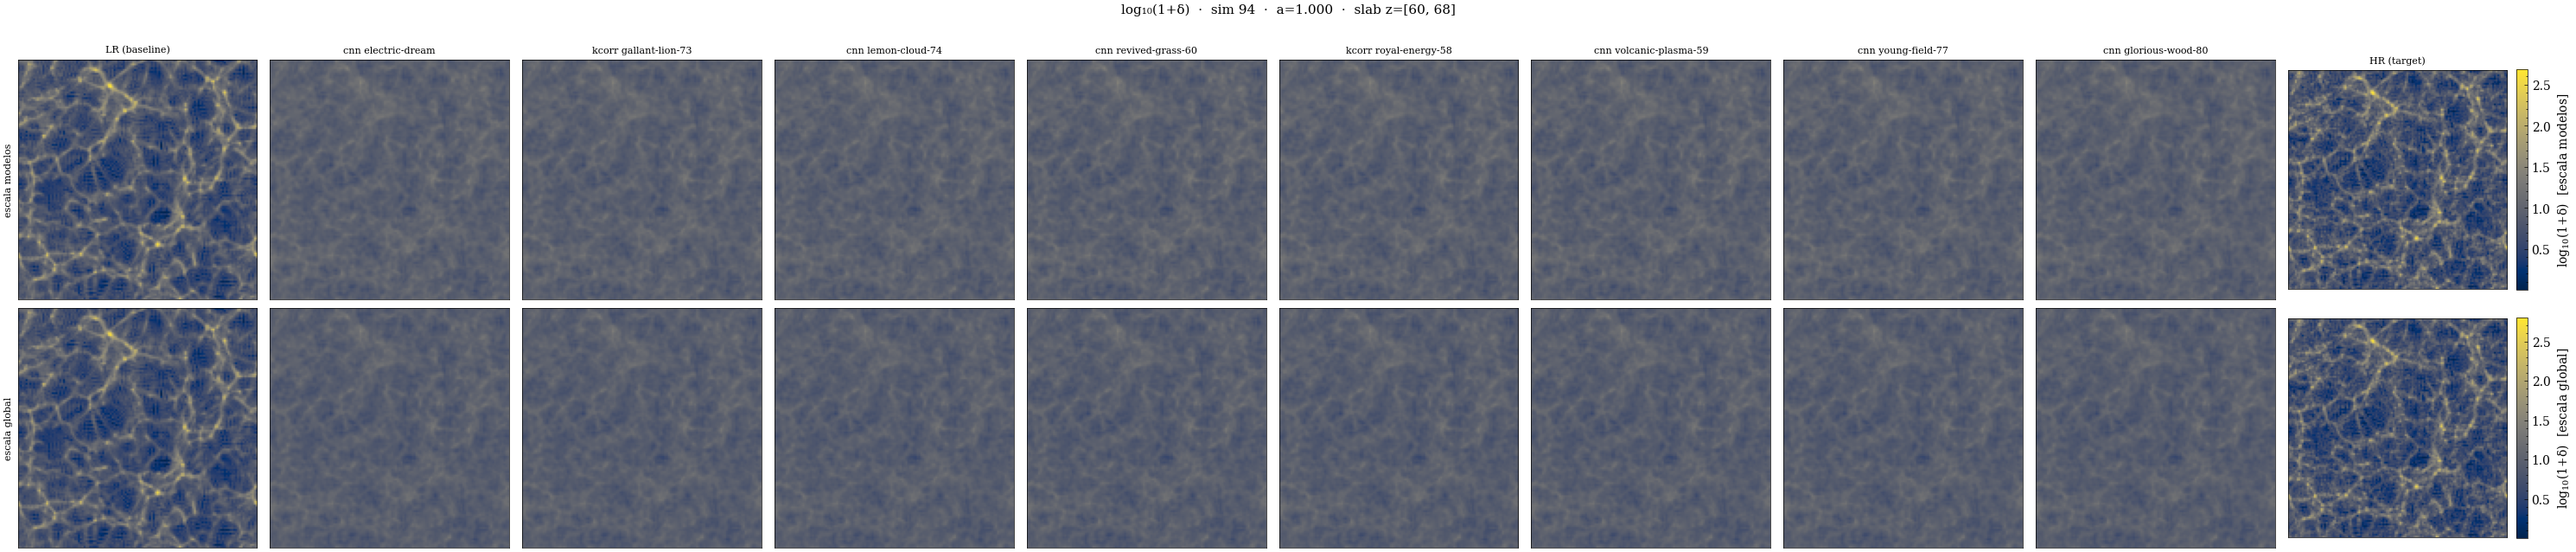

Guardado: density_projections.pdf  |  10 columnas × 2 filas


In [ ]:
# ── Limpiar tensores residuales ───────────────────────────────────────────────
_to_clean = ["pos_pm", "pos_lr", "vel_lr", "pos_hr", "vel_hr",
             "pos_pm_cpu", "pos_hr_cpu", "delta_pm", "delta_hr",
             "params", "model", "params_v", "model_v", "pos_eval",
             "snap_pos", "snap_hr", "p_pm", "p_hr", "avals", "k"]
for _var in _to_clean:
    if _var in globals():
        del globals()[_var]
jax.effects_barrier()
jax.clear_caches()

# ── Config — parámetros explícitos para garantizar comparabilidad ─────────────
SIM_ID_VIZ  = TEST_SIM_IDS[-1]
SNAP_VIZ    = SNAP_EVAL[-1]        # índice en el array de 50 snapshots
SNAP_VIZ_i  = SNAP_EVAL.index(SNAP_VIZ)  # índice dentro de SNAP_EVAL → para pos_eval
SLAB_H      = 8                    # grosor total en celdas (mismo para todos)
Z0          = MESH_LR // 2         # z central fijo

# def slab_projection(pos_numpy, n_mesh=MESH_LR, z0=Z0, half_h=SLAB_H//2):
#     """
#     Recibe posiciones en mesh units como numpy array [N, 3].
#     Devuelve proyección log10(1+delta) como numpy 2D.
#     Todos los parámetros son explícitos para garantizar comparabilidad.
#     """
#     # FIX: siempre subir a jnp para positions_to_delta, y siempre wrappear
#     pos = jnp.mod(jnp.array(pos_numpy), n_mesh)
#     delta = positions_to_delta(pos, n_mesh)
#     delta_np = np.asarray(jax.device_get(delta))
#     del pos, delta
#     # Mismo slab para todos
#     sl   = slice(max(z0 - half_h, 0), min(z0 + half_h, n_mesh))
#     proj = delta_np[:, :, sl].sum(axis=-1)
#     return np.log10(np.clip(1.0 + proj, 1e-4, None))
def slab_projection(pos_numpy, n_mesh=MESH_LR, z0=Z0, half_h=SLAB_H//2):
    # pos_numpy en mesh units con posible rango fuera de [0, n_mesh) — mod correcto
    pos = jnp.mod(jnp.array(pos_numpy, dtype=jnp.float32), n_mesh)
    delta = positions_to_delta(pos, n_mesh)
    delta_np = np.asarray(jax.device_get(delta))
    del pos, delta
    sl = slice(max(z0 - half_h, 0), min(z0 + half_h, n_mesh))
    proj = delta_np[:, :, sl].sum(axis=-1)
    return np.log10(np.clip(1.0 + proj, 1e-4, None))

# ── Cargar sim ────────────────────────────────────────────────────────────────
pos_lr_v, vel_lr_v, pos_hr_v, vel_hr_v, avals_v = load_sim(SIM_ID_VIZ)
a_viz = float(avals_v[SNAP_VIZ])
print(f"Visualizando: sim {SIM_ID_VIZ}  |  snapshot {SNAP_VIZ}  |  a={a_viz:.3f}")
print(f"Slab: z=[{Z0-SLAB_H//2}, {Z0+SLAB_H//2}]  grosor={SLAB_H} celdas")

# ── Proyecciones ──────────────────────────────────────────────────────────────
projs = {}
for run_name, pkl_path in RUNS.items():
    corr = infer_model_type(run_name)
    if corr is None:
        # FIX: extraer numpy del slice correcto antes de pasar a slab_projection
        snap_cpu = np.asarray(jax.device_get(pos_lr_v[SNAP_VIZ]))
    else:
        params_v = load_params(pkl_path)
        model_v  = build_kcorr_model() if corr == "kcorr" else build_cnn_model()
        pos_eval, _ = run_ode_with_model(
            pos_lr_v[0], vel_lr_v[0], avals_v, model_v, params_v, corr
        )
        pos_eval_cpu = np.asarray(jax.device_get(pos_eval))
        snap_cpu = pos_eval_cpu[SNAP_VIZ_i]   # mismo índice para todos los modelos
        del pos_eval, pos_eval_cpu, params_v, model_v

    projs[run_name] = slab_projection(snap_cpu)
    del snap_cpu
    jax.effects_barrier()
    jax.clear_caches()

# FIX: HR con exactamente el mismo pipeline que los modelos
snap_hr_cpu = np.asarray(jax.device_get(pos_hr_v[SNAP_VIZ]))
projs["HR (target)"] = slab_projection(snap_hr_cpu)
del snap_hr_cpu, pos_lr_v, vel_lr_v, pos_hr_v, vel_hr_v
jax.effects_barrier()

# ── Escalas ───────────────────────────────────────────────────────────────────
all_keys   = list(RUNS.keys()) + ["HR (target)"]
model_keys = list(RUNS.keys())

# Escala compartida entre todos (para ver el gap real con HR)
vmin_all = min(projs[k].min() for k in all_keys)
vmax_all = max(projs[k].max() for k in all_keys)

# Escala compartida solo modelos (para ver diferencias entre modelos)
vmin_m = min(projs[k].min() for k in model_keys)
vmax_m = max(projs[k].max() for k in model_keys)

print(f"\nRango modelos : [{vmin_m:.3f}, {vmax_m:.3f}]")
print(f"Rango HR      : [{projs['HR (target)'].min():.3f}, {projs['HR (target)'].max():.3f}]")
print(f"Rango global  : [{vmin_all:.3f}, {vmax_all:.3f}]")

# ── Figura: dos filas ─────────────────────────────────────────────────────────
# Fila 1: escala compartida entre modelos → diferencias entre runs
# Fila 2: escala global compartida con HR → gap respecto al target
n_cols = len(all_keys)
fig, axes = plt.subplots(2, n_cols, figsize=(3.0 * n_cols, 6.5))
fig.suptitle(
    f"log₁₀(1+δ)  ·  sim {SIM_ID_VIZ}  ·  a={a_viz:.3f}"
    f"  ·  slab z=[{Z0-SLAB_H//2}, {Z0+SLAB_H//2}]",
    fontsize=11, y=1.01,
)

for col, key in enumerate(all_keys):
    # ── Fila 0: escala de modelos (resalta diferencias entre runs) ────────────
    ax0 = axes[0, col]
    im0 = ax0.imshow(projs[key], cmap="cividis",
                     vmin=vmin_m, vmax=vmax_m, origin="lower")
    ax0.set_title(key, fontsize=8)
    ax0.set_xticks([]); ax0.set_yticks([])
    if col == 0:
        ax0.set_ylabel("escala modelos", fontsize=8)

    # ── Fila 1: escala global (resalta gap con HR) ────────────────────────────
    ax1 = axes[1, col]
    im1 = ax1.imshow(projs[key], cmap="cividis",
                     vmin=vmin_all, vmax=vmax_all, origin="lower")
    ax1.set_xticks([]); ax1.set_yticks([])
    if col == 0:
        ax1.set_ylabel("escala global", fontsize=8)

# Colorbars al final de cada fila
fig.colorbar(im0, ax=axes[0, -1], fraction=0.046, pad=0.04,
             label=r"log$_{10}$(1+δ)  [escala modelos]")
fig.colorbar(im1, ax=axes[1, -1], fraction=0.046, pad=0.04,
             label=r"log$_{10}$(1+δ)  [escala global]")

plt.tight_layout()
plt.savefig("density_projections.pdf", bbox_inches="tight", dpi=300)
plt.show()
print(f"Guardado: density_projections.pdf  |  {n_cols} columnas × 2 filas")

## 10. Guardar resultados agregados

In [ ]:
import json

# Serializar a JSON (k_bins + métricas por run/snapshot)
export = {
    "k_bins" : k_bins.tolist(),
    "snap_eval_indices": SNAP_EVAL,
    "runs"   : {}
}

for run_name in results:
    export["runs"][run_name] = {}
    for snap_idx in SNAP_EVAL:
        d = agg[run_name][snap_idx]
        export["runs"][run_name][str(snap_idx)] = {
            "a"               : d["a"],
            "pk_ratio_mean"   : d["pk_ratio_mean"].tolist(),
            "pk_ratio_std"    : d["pk_ratio_std"].tolist(),
            "cross_corr_mean" : d["cross_corr_mean"].tolist(),
            "cross_corr_std"  : d["cross_corr_std"].tolist(),
            "pos_mse_mean"    : d["pos_mse_mean"],
            "pos_mse_std"     : d["pos_mse_std"],
        }

with open("eval_results.json", "w") as f:
    json.dump(export, f, indent=2)

print("Resultados guardados en eval_results.json")

Resultados guardados en eval_results.json
